In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [6]:
# --- A. Data Input and Tidy Data Preparation ---
years = [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# Data for GDP, GHG, and PEC
gdp_data = {
    'Belgium': [372189.8, 378760.9, 384344.5, 388931.6, 394666.3, 402078.0, 411900.3, 392158.0, 416501.6, 434241.9, 439460.2],
    'Bulgaria': [39169.3, 39541.2, 40884.6, 42122.1, 43278.7, 44382.1, 46063.6, 44582.4, 48051.1, 49991.8, 50935.1],
    'Czechia': [161014.7, 164629.9, 172793.5, 177253.0, 186423.3, 191699.7, 198535.3, 188003.2, 195577.9, 201146.3, 201242.0],
    'Denmark': [250041.9, 253237.4, 258566.6, 266512.4, 274658.3, 279767.0, 284554.9, 279489.5, 297657.1, 298978.2, 300785.8],
    'Germany': [2736940.8, 2796611.2, 2843119.0, 2906299.4, 2987615.0, 3021545.2, 3051087.9, 2925019.6, 3039387.8, 3094378.2, 3067468.0],
    'Estonia': [16734.5, 17290.6, 17608.4, 18153.0, 19175.9, 19885.4, 20626.4, 20031.6, 21685.2, 21419.3, 20831.5],
    'Ireland': [172969.4, 189203.9, 235793.4, 238676.5, 262804.0, 283010.1, 297083.9, 318336.3, 370092.1, 397890.2, 387798.2],
    'Greece': [180522.1, 181952.2, 181536.8, 181479.1, 184152.5, 187954.7, 192234.8, 174556.4, 189663.4, 200557.0, 205234.2],
    'Spain': [1024749.9, 1040331.1, 1082577.6, 1114136.4, 1146402.2, 1173863.3, 1196884.8, 1065944.8, 1137183.4, 1209625.6, 1239392.8],
    'France': [2064504.1, 2085104.4, 2107347.3, 2125471.2, 2169757.8, 2205470.1, 2250184.8, 2082756.5, 2226098.8, 2286576.7, 2319485.4],
    'Croatia': [44852.1, 44602.2, 45638.4, 47218.0, 48767.2, 50183.7, 51739.7, 47439.2, 53431.6, 57325.7, 59228.0],
    'Italy': [1549587.1, 1549565.6, 1563289.6, 1582615.3, 1607995.7, 1621288.1, 1628246.1, 1483849.6, 1616373.2, 1694301.4, 1710832.6],
    'Cyprus': [17625.6, 17312.5, 17904.4, 19081.4, 20178.7, 21444.3, 22704.3, 21973.0, 24475.4, 26238.8, 26964.0],
    'Latvia': [19835.7, 20251.2, 21017.4, 21553.7, 22286.3, 23246.8, 23403.8, 22591.9, 24160.3, 24621.4, 24389.6],
    'Lithuania': [31944.4, 33149.5, 34088.6, 34999.4, 36613.6, 38414.4, 40211.2, 40228.4, 42801.0, 43856.1, 44180.5],
    'Luxembourg': [44933.8, 46112.5, 47159.1, 49506.8, 50158.9, 50967.1, 52368.4, 52101.3, 55711.7, 55100.3, 55155.1],
    'Hungary': [102146.4, 106573.8, 110474.2, 113168.3, 117835.6, 124441.6, 130759.7, 125086.4, 134121.3, 139690.5, 138549.1],
    'Malta': [7668.3, 8253.5, 9047.5, 9416.5, 10637.9, 11402.7, 11868.5, 11458.2, 12994.9, 13317.6, 14732.1],
    'Netherlands': [647829.6, 658276.6, 672236.0, 688532.9, 707684.8, 723669.6, 740314.6, 711679.6, 756350.5, 794222.8, 789472.6],
    'Austria': [303796.7, 306092.8, 310082.8, 316647.9, 323842.9, 331887.9, 337712.4, 316374.9, 331950.3, 349646.5, 346897.4],
    'Poland': [388238.2, 403459.1, 421339.5, 434111.0, 456478.4, 484989.4, 507204.1, 496879.7, 531299.4, 559221.6, 560617.5],
    'Portugal': [167948.1, 169193.2, 171883.0, 175327.8, 181139.4, 186476.3, 191596.4, 175876.6, 185653.2, 198622.6, 204779.8],
    'Romania': [137006.5, 142645.6, 147149.0, 151357.4, 163761.8, 172596.0, 179431.3, 172975.3, 182640.1, 190288.5, 194584.7],
    'Slovenia': [34938.9, 35904.2, 36763.5, 37879.1, 39839.1, 41583.7, 43041.3, 41283.0, 44757.8, 45952.1, 47043.9],
    'Slovakia': [72097.4, 74049.8, 77883.2, 79400.3, 81682.8, 85000.9, 86935.4, 84687.7, 89514.5, 89906.0, 91855.3],
    'Finland': [187852.1, 186954.1, 187826.2, 192657.0, 199021.1, 201395.4, 204113.7, 199029.2, 204355.9, 205915.2, 203981.5],
    'Sweden': [386923.6, 395806.5, 413175.5, 421981.0, 429926.2, 437536.9, 448948.9, 440267.2, 463274.9, 469091.0, 468133.8]
}

ghg_data = {
    'Belgium': [120.23576, 114.50296, 118.67012, 117.22892, 116.6131, 117.36547, 116.32442, 106.96791, 109.76429, 102.97658, 98.22123],
    'Bulgaria': [54.31882, 57.33386, 60.49588, 57.86604, 59.65782, 55.29483, 53.98726, 47.98531, 54.10155, 58.45965, 45.36492],
    'Czechia': [128.51417, 126.00264, 126.41542, 128.43337, 129.36362, 126.94927, 121.5337, 112.03299, 117.40203, 115.00685, 102.48664],
    'Denmark': [57.54966, 53.34363, 50.59963, 52.59637, 50.23582, 50.07453, 46.10571, 43.47568, 44.38287, 42.78103, 39.28582],
    'Germany': [933.98593, 893.54949, 901.826, 897.28723, 882.23205, 852.85834, 798.04805, 732.99334, 761.42676, 748.79271, 672.02032],
    'Estonia': [21.82485, 20.98727, 17.92095, 19.53923, 20.76706, 19.95558, 14.51246, 11.33732, 12.56818, 14.14911, 10.86246],
    'Ireland': [58.00772, 58.0949, 60.42635, 62.71519, 61.94062, 61.59539, 59.77293, 57.61866, 60.22768, 58.96044, 54.93435],
    'Greece': [103.35445, 99.93725, 96.07275, 92.39752, 96.24621, 93.01074, 86.30612, 75.87408, 78.01311, 77.76987, 71.93467],
    'Spain': [319.58932, 320.36287, 331.96498, 320.39049, 333.28375, 327.57742, 308.89405, 269.80325, 287.56863, 292.2969, 269.96764],
    'France': [489.71931, 456.77804, 460.10006, 462.54004, 465.0541, 445.75797, 436.0623, 396.07561, 419.75637, 403.44494, 376.39688],
    'Croatia': [25.03215, 24.29759, 24.75426, 24.92344, 25.77249, 24.64599, 24.81574, 23.8981, 24.42855, 24.52328, 25.41895],
    'Italy': [454.16399, 432.86146, 443.41422, 439.99819, 433.20775, 429.15501, 417.36168, 379.96336, 412.15202, 412.92768, 384.74178],
    'Cyprus': [7.92367, 8.2791, 8.32588, 8.77007, 8.93554, 8.82581, 8.42426, 8.06981, 8.18503, 8.34285, 8.5035],
    'Latvia': [10.8216, 10.73548, 10.77139, 10.76332, 10.80336, 11.27555, 11.13986, 10.5073, 10.72528, 10.11756, 9.98066],
    'Lithuania': [19.47703, 19.37549, 19.68419, 19.73753, 19.86211, 19.51923, 19.7262, 19.60955, 19.76081, 18.43247, 17.88831],
    'Luxembourg': [11.30774, 10.809, 10.33702, 10.10198, 10.2839, 10.58545, 10.75258, 9.0633, 9.4044, 8.21429, 7.76889],
    'Hungary': [58.88269, 59.22292, 62.40266, 63.0329, 65.21993, 65.17739, 64.93476, 62.93877, 64.01681, 59.72797, 54.31259],
    'Malta': [2.83484, 2.8458, 2.1467, 1.85173, 2.01718, 2.01842, 2.12694, 2.08626, 2.10049, 2.25967, 2.24593],
    'Netherlands': [195.78826, 187.54917, 194.64641, 195.24841, 192.53618, 187.37183, 181.54428, 164.97823, 167.21094, 153.55284, 142.63653],
    'Austria': [80.86775, 77.21516, 79.35898, 80.3194, 82.63536, 79.44149, 80.64067, 74.67879, 78.07325, 73.51515, 68.69592],
    'Poland': [393.04604, 380.43532, 383.03467, 393.85067, 408.46181, 408.49635, 386.17758, 371.25856, 399.2629, 380.84445, 348.43637],
    'Portugal': [63.53466, 63.41007, 67.59192, 65.74332, 70.88785, 67.17157, 63.60505, 57.49665, 56.17358, 56.40363, 53.24953],
    'Romania': [117.86519, 118.11056, 116.8021, 114.8391, 117.80406, 118.54509, 115.31193, 111.52122, 115.375, 109.66726, 103.86245],
    'Slovenia': [18.32355, 16.66047, 16.85022, 17.73432, 17.81851, 17.65556, 17.13171, 15.90349, 16.04933, 15.55767, 14.80443],
    'Slovakia': [41.69086, 39.6885, 40.4556, 41.00656, 42.14651, 42.00485, 39.65993, 36.95776, 40.92057, 36.88044, 36.11474],
    'Finland': [62.81761, 58.65111, 55.07572, 57.94965, 55.07374, 56.1213, 52.72854, 47.76958, 47.80341, 45.69738, 41.10349],
    'Sweden': [55.20985, 53.48192, 53.28369, 53.19826, 52.29434, 51.43433, 50.19645, 45.98193, 47.72178, 44.20169, 44.38597]
}

pec_data = {
    'Belgium': [48.63, 45.24, 45.66, 48.45, 48.49, 46.44, 48.40, 43.85, 48.75, 45.22, 42.05],
    'Bulgaria': [16.51, 17.26, 17.96, 17.67, 18.32, 18.23, 18.04, 17.07, 18.57, 18.94, 16.58],
    'Czechia': [40.67, 38.98, 39.44, 39.74, 40.36, 40.48, 39.74, 37.58, 39.53, 38.62, 35.49],
    'Denmark': [17.82, 16.91, 16.82, 17.28, 17.40, 17.41, 16.88, 15.47, 16.32, 15.71, 15.35],
    'Germany': [308.29, 293.60, 295.93, 297.63, 298.12, 291.95, 285.24, 262.15, 271.49, 261.06, 237.17],
    'Estonia': [5.72, 5.48, 4.76, 5.96, 5.78, 5.60, 4.79, 4.32, 4.45, 4.72, 4.11],
    'Ireland': [12.99, 13.17, 13.92, 14.66, 14.56, 14.63, 14.69, 13.49, 13.83, 14.34, 14.06],
    'Greece': [23.42, 23.29, 23.39, 23.06, 23.24, 22.61, 22.29, 19.24, 20.33, 20.94, 19.88],
    'Spain': [115.67, 113.82, 118.16, 118.43, 124.92, 124.30, 120.63, 105.03, 111.36, 113.54, 110.06],
    'France': [250.51, 239.87, 244.46, 240.08, 239.29, 238.90, 235.53, 208.04, 224.77, 205.89, 209.56],
    'Croatia': [8.00, 7.60, 7.96, 8.05, 8.33, 8.18, 8.21, 7.76, 8.27, 8.30, 8.54],
    'Italy': [152.05, 142.66, 149.12, 148.04, 149.01, 147.29, 145.94, 132.35, 145.61, 139.65, 134.82],
    'Cyprus': [2.18, 2.22, 2.27, 2.42, 2.53, 2.55, 2.54, 2.20, 2.31, 2.48, 2.52],
    'Latvia': [4.36, 4.36, 4.27, 4.29, 4.47, 4.69, 4.56, 4.26, 4.47, 4.27, 4.27],
    'Lithuania': [5.80, 5.75, 5.79, 6.04, 6.16, 6.37, 6.28, 6.23, 6.63, 6.31, 6.34],
    'Luxembourg': [4.30, 4.19, 4.14, 4.15, 4.29, 4.46, 4.50, 3.94, 4.19, 3.79, 3.65],
    'Hungary': [22.41, 21.99, 23.30, 23.66, 24.46, 24.48, 24.57, 23.89, 24.93, 23.87, 22.11],
    'Malta': [0.87, 0.89, 0.75, 0.71, 0.81, 0.82, 0.87, 0.74, 0.77, 0.89, 0.91],
    'Netherlands': [66.21, 62.32, 64.06, 65.10, 65.35, 64.76, 63.73, 58.44, 60.79, 56.20, 53.81],
    'Austria': [32.07, 30.80, 31.66, 32.04, 32.82, 31.83, 32.27, 29.85, 31.62, 30.34, 29.35],
    'Poland': [93.40, 89.49, 90.05, 94.83, 99.08, 104.06, 100.19, 96.84, 103.94, 98.40, 93.27],
    'Portugal': [21.04, 20.68, 21.65, 21.76, 22.81, 22.66, 22.07, 19.50, 19.53, 20.77, 20.71],
    'Romania': [30.41, 30.07, 30.75, 30.65, 32.46, 32.57, 32.07, 30.93, 33.09, 31.00, 29.95],
    'Slovenia': [6.65, 6.39, 6.35, 6.56, 6.74, 6.67, 6.54, 6.15, 6.34, 6.21, 5.92],
    'Slovakia': [16.39, 15.20, 15.80, 16.03, 16.78, 16.28, 15.98, 15.18, 16.44, 15.40, 15.26],
    'Finland': [31.99, 32.67, 31.20, 32.26, 32.18, 32.82, 32.07, 29.93, 31.51, 30.20, 31.33],
    'Sweden': [46.42, 45.94, 43.82, 45.34, 46.33, 47.23, 45.77, 41.28, 43.30, 42.55, 41.41]
}


def create_tidy_df(data, name):
    df = pd.DataFrame(data).T.stack().reset_index()
    df.columns = ['Country', 'Year', name]
    df['Year'] = df['Year'].astype(int)
    return df

data_gdp = create_tidy_df(gdp_data, 'GDP')
data_ghg = create_tidy_df(ghg_data, 'GHG')
data_pec = create_tidy_df(pec_data, 'PEC')

# Merge all DataFrames into one (Tidy Data)
eu_data = data_gdp.merge(data_ghg, on=['Country', 'Year']).merge(data_pec, on=['Country', 'Year'])

# --- B. Log Transformation and Grouped Regression ---
eu_data['ln_GDP'] = np.log(eu_data['GDP'])
eu_data['ln_GHG'] = np.log(eu_data['GHG'])
eu_data['ln_PEC'] = np.log(eu_data['PEC'])

beta_results = []
countries = eu_data['Country'].unique()
X_var = 'ln_GDP' # Independent variable

for country in countries:
    country_data = eu_data[eu_data['Country'] == country].copy()
    X = sm.add_constant(country_data[X_var]) # Add constant (Intercept)

    # Regression: ln_GHG = Intercept + Beta_GHG * ln_GDP
    model_ghg = sm.OLS(country_data['ln_GHG'], X).fit()
    beta_ghg = model_ghg.params.get(X_var)

    # Regression: ln_PEC = Intercept + Beta_PEC * ln_GDP
    model_pec = sm.OLS(country_data['ln_PEC'], X).fit()
    beta_pec = model_pec.params.get(X_var)

    beta_results.append({
        'Country': country,
        'Beta_ln_GHG': beta_ghg,
        'Beta_ln_PEC': beta_pec
    })

# DataFrame with final Beta coefficients (input for cluster analysis)
beta_df = pd.DataFrame(beta_results).set_index('Country')

print("\n--- Table of Beta Coefficients (Elasticities) ---")
print(beta_df.head())


--- Table of Beta Coefficients (Elasticities) ---
          Beta_ln_GHG  Beta_ln_PEC
Country                           
Belgium     -0.970732    -0.349166
Bulgaria    -0.472385     0.163692
Czechia     -0.590165    -0.205662
Denmark     -1.568140    -0.535726
Germany     -1.893378    -1.225589


C:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



--- Average Beta Coefficients by Cluster (Centroids) ---
                 Beta_ln_GHG  Beta_ln_PEC
Cluster_Name                             
High-decoupling    -1.556936    -0.633013
Low-decoupling     -0.287438     0.064866


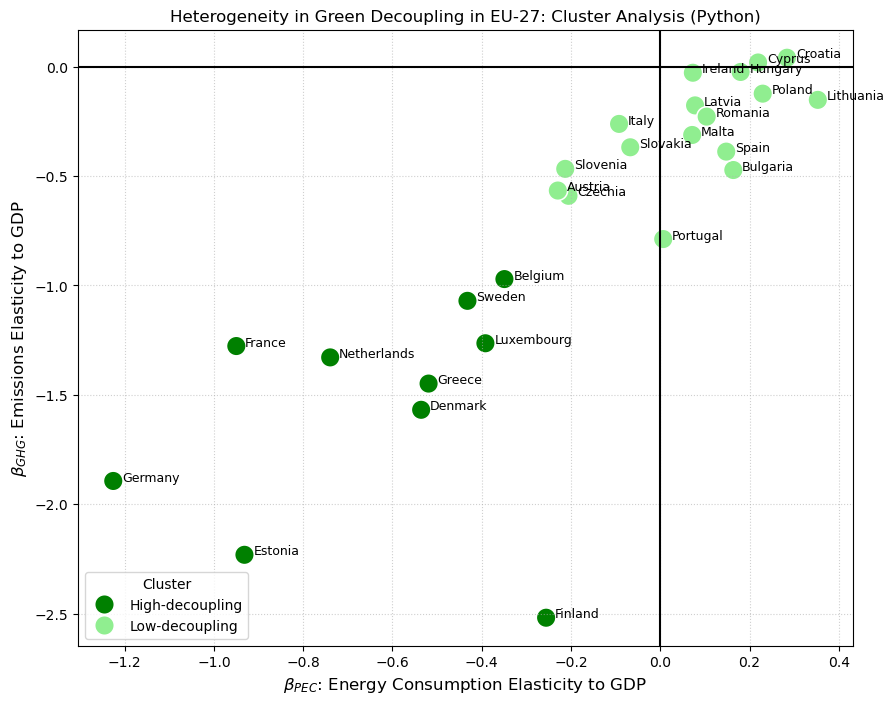


Analysis complete.


In [7]:

# --- A. K-Means Cluster Analysis ---
X_cluster = beta_df[['Beta_ln_GHG', 'Beta_ln_PEC']]

# Apply K-Means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
beta_df['Cluster_ID'] = kmeans.fit_predict(X_cluster)

# Naming clusters based on the mean of Beta_GHG
cluster_means = beta_df.groupby('Cluster_ID').mean()

# The cluster with the more negative Beta_GHG (better decoupling) is 'High-decoupling'
if cluster_means.loc[0, 'Beta_ln_GHG'] < cluster_means.loc[1, 'Beta_ln_GHG']:
    cluster_mapping = {0: 'High-decoupling', 1: 'Low-decoupling'}
else:
    cluster_mapping = {1: 'High-decoupling', 0: 'Low-decoupling'}

beta_df['Cluster_Name'] = beta_df['Cluster_ID'].map(cluster_mapping)

print("\n--- Average Beta Coefficients by Cluster (Centroids) ---")
print(beta_df.groupby('Cluster_Name')[['Beta_ln_GHG', 'Beta_ln_PEC']].mean())

# --- B. Visualization ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=beta_df.reset_index(),
    x='Beta_ln_PEC',
    y='Beta_ln_GHG',
    hue='Cluster_Name',
    style='Cluster_Name',
    s=200,
    palette={'High-decoupling': '#008000', 'Low-decoupling': '#90EE90'}, # Dark Green and Light Green
    markers={'High-decoupling': 'o', 'Low-decoupling': 'o'} # Both clusters as circles ('o')

)

# Adding country labels
for country, row in beta_df.iterrows():
    plt.text(row['Beta_ln_PEC'] + 0.02, row['Beta_ln_GHG'], country, fontsize=9)

# Zero lines for reference
plt.axhline(0, color='black', linestyle='-')
plt.axvline(0, color='black', linestyle='-')

# Plot settings
plt.xlabel(r'$\beta_{PEC}$: Energy Consumption Elasticity to GDP', fontsize=12)
plt.ylabel(r'$\beta_{GHG}$: Emissions Elasticity to GDP', fontsize=12)
plt.title('Heterogeneity in Green Decoupling in EU-27: Cluster Analysis (Python)')
plt.legend(title='Cluster', loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\nAnalysis complete.")



## 4. Results Interpretation and Policy Implications

### Cluster Characteristics

The K-Means Clustering method successfully partitioned the EU-27 economies into two distinct groups based on their emissions elasticity to GDP ($\beta_{GHG}$):

* **High-Decoupling Cluster:** Characterized by a **highly negative** $\beta_{GHG}$ (e.g., -1.56, visible in the table/plot). This signifies economic growth is strongly separated from GHG emissions. Countries like **Germany** and **Estonia** are clear leaders in this regime.

* **Low-Decoupling Cluster:** Characterized by a $\beta_{GHG}$ closer to zero (e.g., -0.29). This group shows weaker separation, meaning economic growth results in only marginal decreases in emissions. Countries in Southern and Eastern Europe (e.g., **Croatia, Cyprus**) fall here, indicating a higher need for targeted policy interventions.

### Conclusion

The structural heterogeneity revealed by the cluster analysis is critical for developing effective, tailored ESCB statistical indicators and policy recommendations, directly supporting the ECB's mandate.